# Loading Data and Importing Packages

In [1]:
import pandas as pd
import numpy as np 
df = pd.read_csv(r"C:\Users\AlexaJohnston\Springboard\Enron_Investigation_Capstone\clean_emails.csv")

# Summary Statistics

In [2]:
df.head()

,from,to,subject,date,custodian,folder_source,body_clean
0,ohi_supporters@operationhope.org,klay@enron.com,The Latest Edition of Operation HOPE Inc.'s El...,2001-11-13 19:14:52+00:00,lay-k,deleted_items,Here It Is !!! [IMAGE]or copy and paste the f...
1,djtheroux@independent.org,lighthouse@independent.org,"THE LIGHTHOUSE: November 26, 2001",2001-11-27 01:37:47+00:00,lay-k,deleted_items,"THE LIGHTHOUSE""Enlightening Ideas for Public P..."
2,ggalata@enron.co.uk,kenneth.lay@enron.com,Franco Bernabe's tel number,1999-08-02 15:33:00+00:00,lay-k,discussion_threads,"Ken,I finally found Franco Bernabe's work numb..."
3,rosalee.fleming@enron.com,expense.report@enron.com,Approval of Jeff Skilling's Expense Report,1999-08-19 09:18:00+00:00,lay-k,discussion_threads,Kenneth Lay has approved the attached expense ...
4,corry.bentley@enron.com,kenneth.lay@enron.com,Sacrifice,2000-08-21 09:36:00+00:00,lay-k,discussion_threads,"Here in my group, and all over Enron, I see pe..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2476 entries, 0 to 2475
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   from           2476 non-null   object
 1   to             2476 non-null   object
 2   subject        2392 non-null   object
 3   date           2476 non-null   object
 4   custodian      2476 non-null   object
 5   folder_source  2476 non-null   object
 6   body_clean     2395 non-null   object
dtypes: object(7)
memory usage: 135.5+ KB


In [4]:
df['custodian'].value_counts()

custodian
skilling-j    1343
lay-k         1133
Name: count, dtype: int64

In [5]:
df['folder_source'].value_counts()

folder_source
discussion_threads    1533
deleted_items          485
sent                   335
sent_items              67
notes_inbox             52
_sent                    2
_sent_mail               2
Name: count, dtype: int64

## Email Length

In [6]:
df = df.rename(columns={'body_clean':'body'})
df['text_length'] = df['body'].str.len()
df['text_length'].describe()

count     2395.000000
mean      1034.202505
std       1624.745699
min          1.000000
25%        211.000000
50%        546.000000
75%       1237.000000
max      24911.000000
Name: text_length, dtype: float64

## Time Distribution

In [7]:
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')

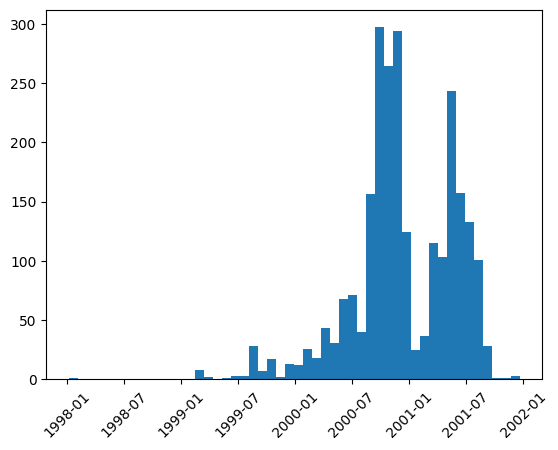

In [8]:
import matplotlib.pyplot as plt
plt.hist(df['date_parsed'], bins=50) 
plt.xticks(rotation=45)
plt.show()

# Word Analysis

## Cleaning Text

In [9]:
import re 
def clean_text(text): 
    text = str(text).lower() # normalizes text for analysis
    text = re.sub(r'\n', ' ', text) # removes any enter/ new lines
    text = re.sub(r'[^a-z\s]', '', text) # removes all punctuation and special characters
    text = re.sub(r'\s+', ' ', text) # removes extra spaces
    text = text = re.sub(r'(.)\1{10,}', '', text) # removes strings greater than 10 of the same character
    return text.strip() # removes whitespaces and returns the final clean text

In [10]:
df['body_clean'] = df['body'].apply(clean_text)

## Word Count

In [11]:
from collections import Counter
all_words = ' '.join(df['body_clean']).split()
word_counts = Counter(all_words)
word_counts.most_common(50)

[('the', 15286),
 ('to', 11063),
 ('and', 8593),
 ('of', 7514),
 ('in', 5708),
 ('a', 5652),
 ('for', 4438),
 ('you', 4370),
 ('is', 3664),
 ('i', 3281),
 ('on', 3176),
 ('that', 2865),
 ('will', 2681),
 ('this', 2651),
 ('be', 2582),
 ('with', 2465),
 ('at', 2261),
 ('have', 2233),
 ('we', 2184),
 ('your', 2089),
 ('as', 1836),
 ('are', 1727),
 ('it', 1564),
 ('from', 1518),
 ('our', 1506),
 ('enron', 1440),
 ('or', 1401),
 ('by', 1362),
 ('if', 1212),
 ('not', 1193),
 ('would', 1151),
 ('has', 1134),
 ('an', 1123),
 ('please', 1066),
 ('me', 928),
 ('new', 878),
 ('was', 867),
 ('can', 822),
 ('all', 818),
 ('my', 809),
 ('any', 796),
 ('he', 771),
 ('us', 771),
 ('time', 725),
 ('business', 690),
 ('about', 686),
 ('email', 673),
 ('am', 673),
 ('been', 647),
 ('information', 643)]

## Frequency Analysis

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(ngram_range=(2,3), stop_words='english') # This says identify 2 (bigram) and 3 (trigram) word phrases and exclude common English filler words ("the", "a", etc.), works like a translator
X = vectorizer.fit_transform(df['body_clean']) # Uses fit_transform to learn the vocabulary in the email and count the number of occurrences.
sum_words = X.sum(axis=0)

In [13]:
words_freq = []
for word, idx in vectorizer.vocabulary_.items(): # .vocabulary_ creates a dictionary from the translator with the word/phrase and it's frequency value's position (idx) in the sum_words matrix
    frequency = sum_words[0, idx] 
    words_freq.append((word, frequency))
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
words_freq[:50]

[('let know', np.int64(287)),
 ('communicationsenron communications', np.int64(191)),
 ('look forward', np.int64(183)),
 ('image image', np.int64(166)),
 ('notional value', np.int64(108)),
 ('day trailing', np.int64(108)),
 ('trailing avg', np.int64(108)),
 ('day trailing avg', np.int64(108)),
 ('image image image', np.int64(102)),
 ('ken lay', np.int64(96)),
 ('jeff skilling', np.int64(89)),
 ('feel free', np.int64(73)),
 ('products offered', np.int64(69)),
 ('na na', np.int64(69)),
 ('dear mr', np.int64(68)),
 ('executive committee', np.int64(67)),
 ('mr lay', np.int64(65)),
 ('new york', np.int64(65)),
 ('north america', np.int64(64)),
 ('executive summary', np.int64(62)),
 ('vice president', np.int64(60)),
 ('web site', np.int64(58)),
 ('mr skilling', np.int64(58)),
 ('life date', np.int64(57)),
 ('unterberg towbin', np.int64(56)),
 ('external users', np.int64(56)),
 ('external transactions', np.int64(54)),
 ('average daily', np.int64(54)),
 ('transactions day', np.int64(54)),
 ('u

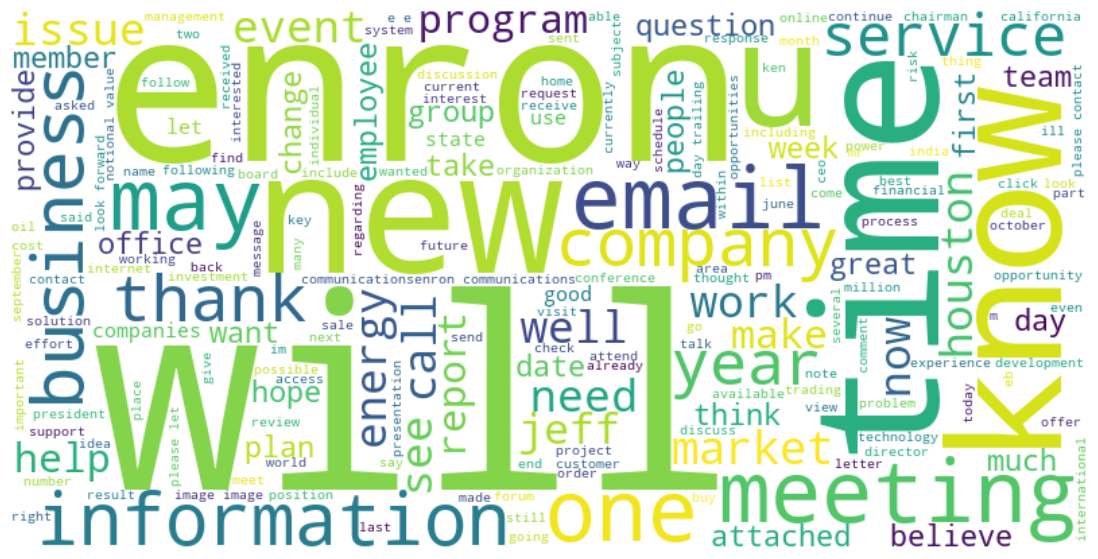

In [14]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['body_clean']))
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Keyword Analysis

In [15]:
keywords = ['hide', 'cover up', 'know', 'aware', 'misrepresent', 'rush', 'urgent', 'secret', 'write off', 'nobody will find out', 'not hurting anyone', 'fix it later', 'told to do it', 'call my mobile', 'call my cell', 'come by my office', 'illegal', 'failed investment', 'grey area', 'gray area', 'they owe it to me', 'do not volunteer information', "don't volunteer information", 'not ethical', 'unethical', 'off the books', 'off the record', 'backdate', 'no inspection', 'pull earnings forward', 'special fees', 'friendly payments', 'send to my gmail', "don't leave a trail", "don't text me", 'do not leave a trail', 'do not text me', "let's take this offline", 'tell you on the phone', 'tyop', "let's discuss later", 'ldl', 'message me on facebook', 'message me on twitter', 'message me on linkedin', 'cook me up', 'money was illegal', 'money is illegal', 'material, non-public information', 'blame freelancers', 'expected to announce', 'leak', 'do not share', "don't share", 'deserve to get paid', 'top secret', 'breach', 'delete after reading', 'not on the record', 'make it disappear', 'do not share with accounts', "don't share with accounts", 'adjust entries quietly', 'personal account', 'gift or incentive', 'untraceable payment']
keywords = [word.lower() for word in keywords]
keyword_hits = []
for text in df['body_clean']:
    count = 0
    for word in keywords:
        count += text.count(word)
    keyword_hits.append(count)
df['keyword_hits'] = keyword_hits
df.head()

,from,to,subject,date,custodian,folder_source,body,text_length,date_parsed,body_clean,keyword_hits
0,ohi_supporters@operationhope.org,klay@enron.com,The Latest Edition of Operation HOPE Inc.'s El...,2001-11-13 19:14:52+00:00,lay-k,deleted_items,Here It Is !!! [IMAGE]or copy and paste the f...,207.0,2001-11-13 19:14:52+00:00,here it is imageor copy and paste the followin...,0
1,djtheroux@independent.org,lighthouse@independent.org,"THE LIGHTHOUSE: November 26, 2001",2001-11-27 01:37:47+00:00,lay-k,deleted_items,"THE LIGHTHOUSE""Enlightening Ideas for Public P...",560.0,2001-11-27 01:37:47+00:00,the lighthouseenlightening ideas for public po...,1
2,ggalata@enron.co.uk,kenneth.lay@enron.com,Franco Bernabe's tel number,1999-08-02 15:33:00+00:00,lay-k,discussion_threads,"Ken,I finally found Franco Bernabe's work numb...",474.0,1999-08-02 15:33:00+00:00,keni finally found franco bernabes work number...,1
3,rosalee.fleming@enron.com,expense.report@enron.com,Approval of Jeff Skilling's Expense Report,1999-08-19 09:18:00+00:00,lay-k,discussion_threads,Kenneth Lay has approved the attached expense ...,71.0,1999-08-19 09:18:00+00:00,kenneth lay has approved the attached expense ...,0
4,corry.bentley@enron.com,kenneth.lay@enron.com,Sacrifice,2000-08-21 09:36:00+00:00,lay-k,discussion_threads,"Here in my group, and all over Enron, I see pe...",503.0,2000-08-21 09:36:00+00:00,here in my group and all over enron i see peop...,0


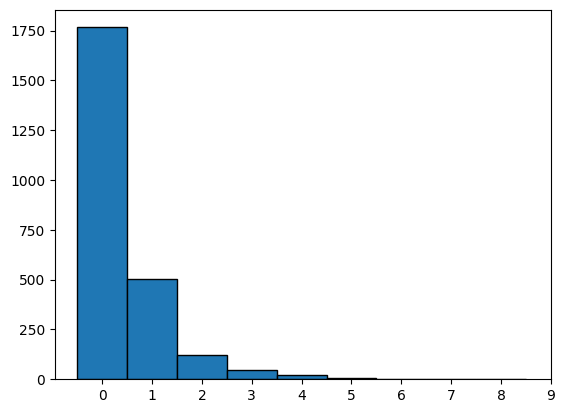

In [16]:
_ = plt.hist(df['keyword_hits'], bins=np.arange(10)-0.5, edgecolor='black', linewidth=1.0)
_ = plt.xticks(range(10))
plt.show()

In [17]:
df['keyword_hits'].value_counts()

keyword_hits
0     1767
1      505
2      120
3       48
4       23
5        8
10       2
6        2
8        1
Name: count, dtype: int64

In [18]:
keyword_summary = {}
for keyword in keywords:
    total_count = 0
    for body in df['body_clean']:  
        count = body.count(keyword)
        total_count += count
    keyword_summary[keyword] = total_count
keyword_df = pd.DataFrame.from_dict(keyword_summary, orient='index', columns=['total_hits'])
keyword_df = keyword_df.sort_values(by='total_hits', ascending=False)
keyword_df['total_hits'].sum()

np.int64(1061)

In [19]:
keyword_df.loc[keyword_df['total_hits'] == 0]

,total_hits
not on the record,0
gift or incentive,0
let's discuss later,0
message me on facebook,0
message me on twitter,0
message me on linkedin,0
cook me up,0
money was illegal,0
money is illegal,0
"material, non-public information",0


## Custodian Analysis

In [20]:
custodians = df.groupby('custodian')['keyword_hits'].sum().sort_values(ascending=False)
print(custodians)

custodian
skilling-j    564
lay-k         497
Name: keyword_hits, dtype: int64


In [21]:
folders = df.groupby('folder_source')['keyword_hits'].sum().sort_values(ascending=False)
print(folders)

folder_source
discussion_threads    647
deleted_items         188
sent                  173
notes_inbox            30
sent_items             20
_sent_mail              2
_sent                   1
Name: keyword_hits, dtype: int64


# Deception Analysis

## Email Exploration

In [22]:
monthly_counts = df.resample('M', on='date_parsed').size()
print(monthly_counts)

date_parsed
1998-01-31 00:00:00+00:00      1
1998-02-28 00:00:00+00:00      0
1998-03-31 00:00:00+00:00      0
1998-04-30 00:00:00+00:00      0
1998-05-31 00:00:00+00:00      0
1998-06-30 00:00:00+00:00      0
1998-07-31 00:00:00+00:00      0
1998-08-31 00:00:00+00:00      0
1998-09-30 00:00:00+00:00      0
1998-10-31 00:00:00+00:00      0
1998-11-30 00:00:00+00:00      0
1998-12-31 00:00:00+00:00      0
1999-01-31 00:00:00+00:00      0
1999-02-28 00:00:00+00:00      4
1999-03-31 00:00:00+00:00      5
1999-04-30 00:00:00+00:00      1
1999-05-31 00:00:00+00:00      1
1999-06-30 00:00:00+00:00      1
1999-07-31 00:00:00+00:00      3
1999-08-31 00:00:00+00:00     29
1999-09-30 00:00:00+00:00      8
1999-10-31 00:00:00+00:00     17
1999-11-30 00:00:00+00:00      2
1999-12-31 00:00:00+00:00     15
2000-01-31 00:00:00+00:00     15
2000-02-29 00:00:00+00:00     27
2000-03-31 00:00:00+00:00     24
2000-04-30 00:00:00+00:00     33
2000-05-31 00:00:00+00:00     43
2000-06-30 00:00:00+00:00    10

C:\Users\AlexaJohnston\AppData\Local\Temp\ipykernel_23240\1893770875.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.resample('M', on='date_parsed').size()


In [23]:
empty_months = monthly_counts[monthly_counts == 0]
print(empty_months)

date_parsed
1998-02-28 00:00:00+00:00    0
1998-03-31 00:00:00+00:00    0
1998-04-30 00:00:00+00:00    0
1998-05-31 00:00:00+00:00    0
1998-06-30 00:00:00+00:00    0
1998-07-31 00:00:00+00:00    0
1998-08-31 00:00:00+00:00    0
1998-09-30 00:00:00+00:00    0
1998-10-31 00:00:00+00:00    0
1998-11-30 00:00:00+00:00    0
1998-12-31 00:00:00+00:00    0
1999-01-31 00:00:00+00:00    0
2001-10-31 00:00:00+00:00    0
dtype: int64


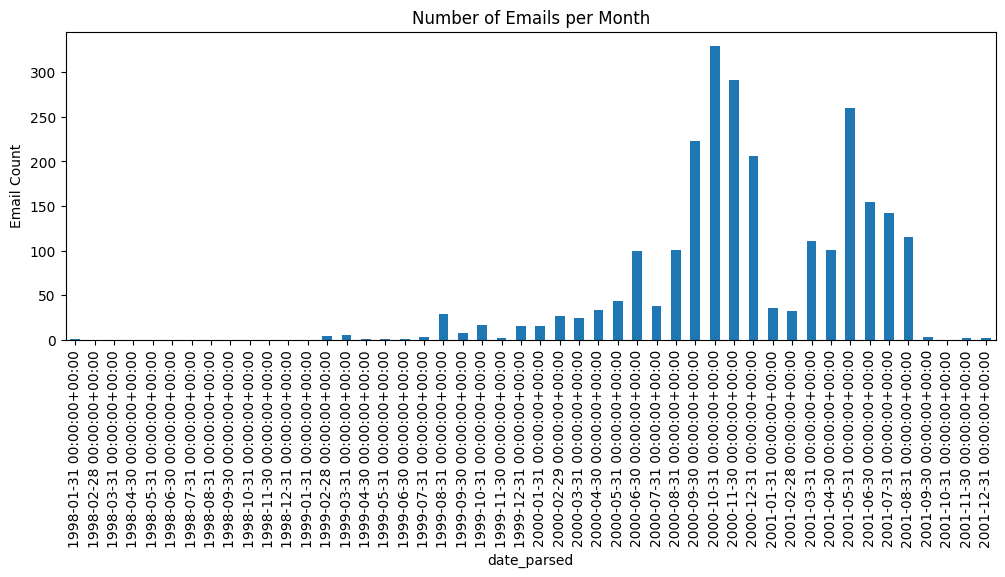

In [24]:
monthly_counts.plot(kind='bar', figsize=(12,4), title="Number of Emails per Month")
_ = plt.ylabel("Email Count")
_ = plt.show()

## Email Length Normalization

In [25]:
word_count = [] 
for body in df['body_clean']: 
    words = body.split()
    count = len(words)
    word_count.append(count)
df['word_count'] = word_count

## Personal Pronoun Usage

In [26]:
personal_pronouns = ['i', 'me', 'my', 'myself', 'we', 'us', 'our']

In [27]:
pronoun_count = []
for body in df['body_clean']:
    words = body.split()
    count = 0
    for word in words:
        if word in personal_pronouns:
            count += 1
    pronoun_count.append(count)
df['pronoun_hits'] = pronoun_count

In [28]:
df['pronoun_rate'] = df['pronoun_hits'] / df['word_count']
df['pronoun_rate'] = df['pronoun_rate'].fillna(0)

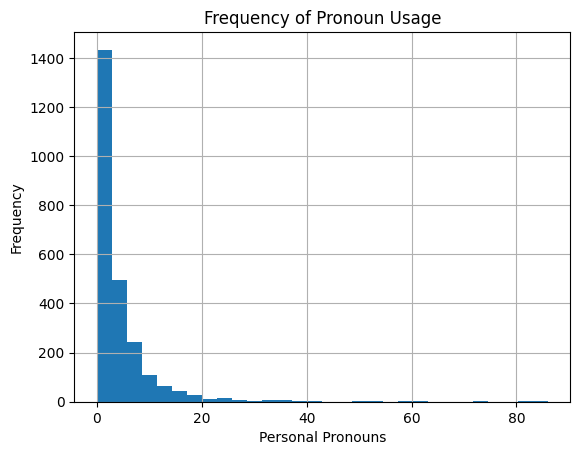

In [29]:
df['pronoun_hits'].hist(bins=30)
_ = plt.xlabel('Personal Pronouns')
_ = plt.ylabel('Frequency') 
_ = plt.title('Frequency of Pronoun Usage')
_ = plt.show()

C:\Users\AlexaJohnston\AppData\Local\Temp\ipykernel_23240\1822353761.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pronoun_trend = df.resample('M', on='date_parsed')['pronoun_rate'].mean()


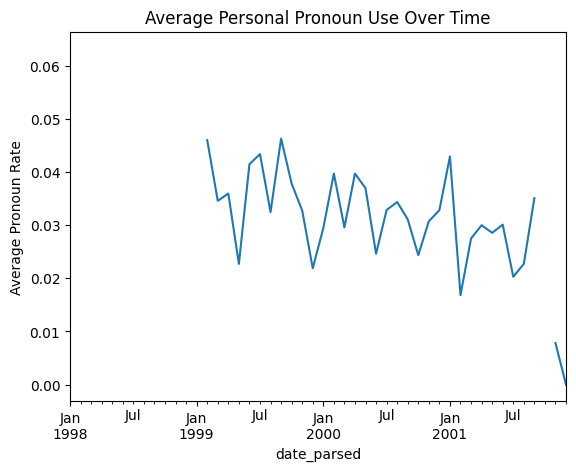

In [30]:
pronoun_trend = df.resample('M', on='date_parsed')['pronoun_rate'].mean()
pronoun_trend.plot()
_ = plt.title("Average Personal Pronoun Use Over Time")
_ = plt.ylabel("Average Pronoun Rate")
_ = plt.show()

## Negation Usage

In [31]:
negations = ['not', "none", "don't", "never", "no", "cannot", "can't", "nothing", "nobody"]

In [32]:
negation_count = []
for body in df['body_clean']:
    words = body.split()
    count = 0
    for word in words:
        if word in negations:
            count += 1
    negation_count.append(count)
df['negation_hits'] = negation_count

In [33]:
df['negation_rate'] = df['negation_hits'] / df['word_count']
df['negation_rate'] = df['negation_rate'].fillna(0)

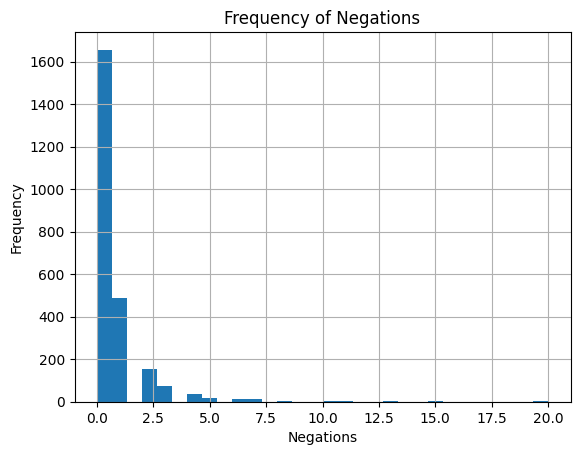

In [34]:
df['negation_hits'].hist(bins=30)
_ = plt.xlabel('Negations')
_ = plt.ylabel('Frequency') 
_ = plt.title('Frequency of Negations')
_ = plt.show()

C:\Users\AlexaJohnston\AppData\Local\Temp\ipykernel_23240\232736363.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  negation_trend = df.resample('M', on='date_parsed')['negation_rate'].mean()


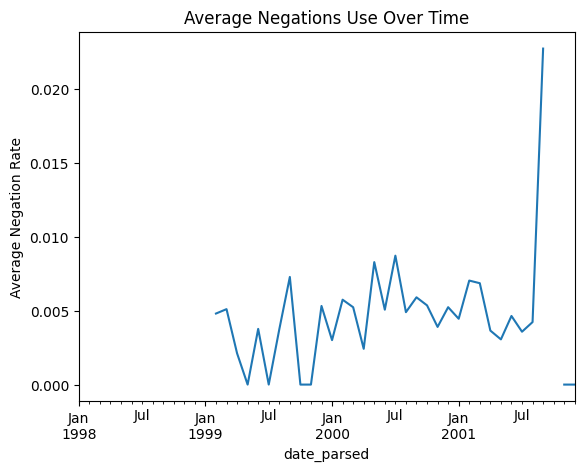

In [35]:
negation_trend = df.resample('M', on='date_parsed')['negation_rate'].mean()
negation_trend.plot()
_ = plt.title("Average Negations Use Over Time")
_ = plt.ylabel("Average Negation Rate")
_ = plt.show()

## Language of Uncertainty

In [36]:
uncertainty = ['maybe', 'might', 'could', 'possibly', 'unsure', 'perhaps']

In [37]:
uncertainty_count = []
for body in df['body_clean']:
    words = body.split()
    count = 0
    for word in words:
        if word in uncertainty:
            count += 1
    uncertainty_count.append(count)
df['uncertainty_hits'] = uncertainty_count

In [38]:
df['uncertainty_rate'] = df['uncertainty_hits'] / df['word_count']
df['uncertainty_rate'] = df['uncertainty_rate'].fillna(0)

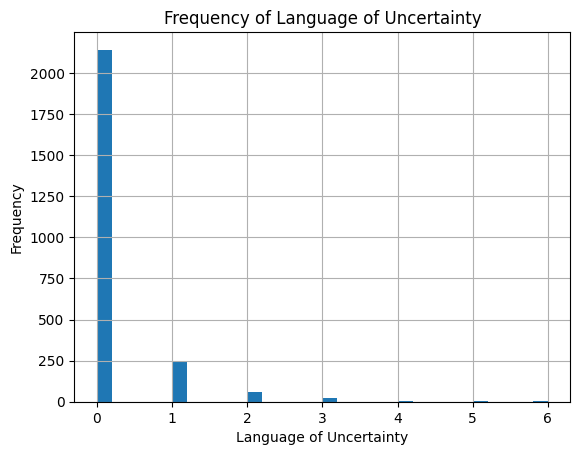

In [39]:
df['uncertainty_hits'].hist(bins=30)
_ = plt.xlabel('Language of Uncertainty')
_ = plt.ylabel('Frequency') 
_ = plt.title('Frequency of Language of Uncertainty')
_ = plt.show()

C:\Users\AlexaJohnston\AppData\Local\Temp\ipykernel_23240\510442623.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  uncertainty_trend = df.resample('M', on='date_parsed')['uncertainty_rate'].mean()


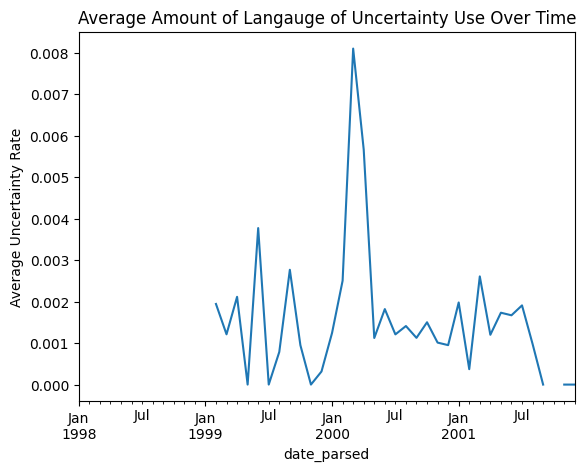

In [40]:
uncertainty_trend = df.resample('M', on='date_parsed')['uncertainty_rate'].mean()
uncertainty_trend.plot()
_ = plt.title("Average Amount of Langauge of Uncertainty Use Over Time")
_ = plt.ylabel("Average Uncertainty Rate")
_ = plt.show()

## Emotive Language

In [41]:
emotive_words = ['happy', 'angry', 'worried', 'fear', 'excited', 'concerned']

In [42]:
emotive_count = []
for body in df['body_clean']:
    words = body.split()
    count = 0
    for word in words:
        if word in emotive_words:
            count += 1
    emotive_count.append(count)
df['emotive_hits'] = emotive_count

In [43]:
df['emotive_rate'] = df['emotive_hits'] / df['word_count']
df['emotive_rate'] = df['emotive_rate'].fillna(0)

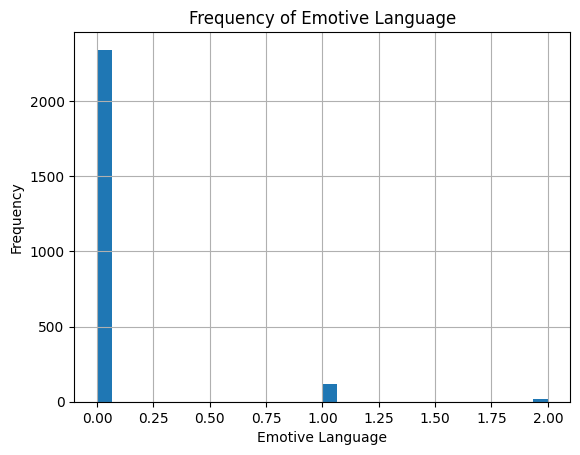

In [44]:
df['emotive_hits'].hist(bins=30)
_ = plt.xlabel('Emotive Language')
_ = plt.ylabel('Frequency') 
_ = plt.title('Frequency of Emotive Language')
_ = plt.show()

C:\Users\AlexaJohnston\AppData\Local\Temp\ipykernel_23240\4265654792.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  emotive_trend = df.resample('M', on='date_parsed')['emotive_rate'].mean()


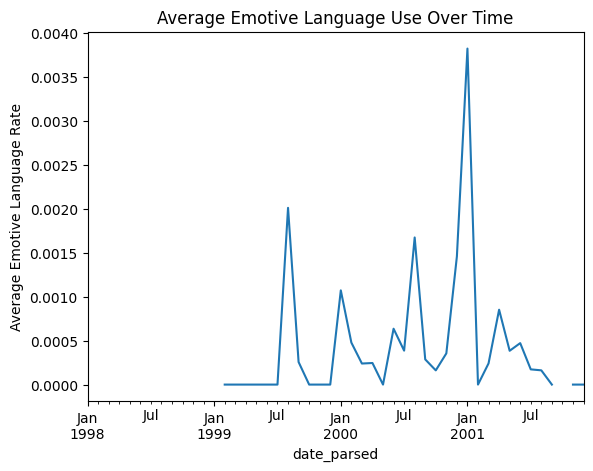

In [45]:
emotive_trend = df.resample('M', on='date_parsed')['emotive_rate'].mean()
emotive_trend.plot()
_ = plt.title("Average Emotive Language Use Over Time")
_ = plt.ylabel("Average Emotive Language Rate")
_ = plt.show()

# Correlation Analysis

In [46]:
corr_deception = df[['pronoun_rate','negation_rate','uncertainty_rate','emotive_rate']].corr()
corr_deception

,pronoun_rate,negation_rate,uncertainty_rate,emotive_rate
pronoun_rate,1.000000,-0.020486,0.112494,0.027321
negation_rate,-0.020486,1.000000,-0.023012,-0.002513
uncertainty_rate,0.112494,-0.023012,1.000000,-0.008219
emotive_rate,0.027321,-0.002513,-0.008219,1.000000


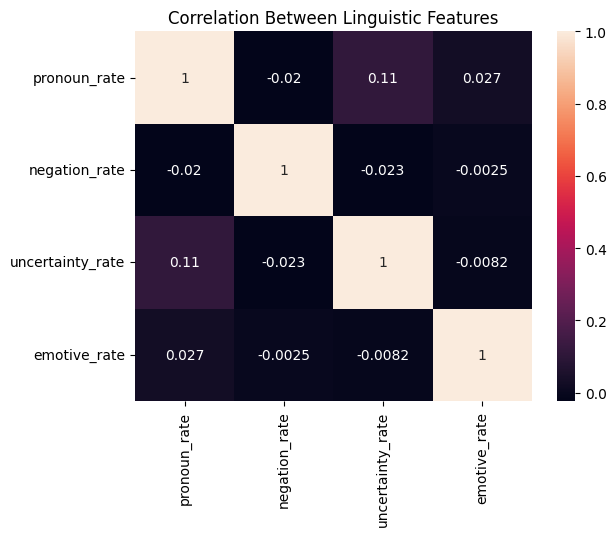

In [47]:
import seaborn as sns
sns.heatmap(corr_deception, annot=True)
_ = plt.title("Correlation Between Linguistic Features")

# Summary

After examining the data, 1,343 emails were marked Skilling and 1,133 emails were marked Lay. The total email count is 2,476 between the two custodians. Out of the 2,476 emails, 1,533 were in discussion threads, 485 were deleted, 406 emails were sent, and 52 were in notes. The average email lenth was about 1,783 characters with minimum being 4 characters and the maximum at 43,172 characters. The majority of the emails are from 2000 and 2001, with very few emails in 1998. 

## Word Analysis
Of the top 50 words used across all emails, only one word stood out as a word not commonly used in general business correspondence. The name "Jeff" appeared 1,463 times across the 2,476 emails. This could be due to the higher amount of emails marked Skilling. From the bigram and trigram analysis, there do not appear to be any phrases that are out of the oridinary from the top 50 list. Within the wordcloud, there are some words that seem to be used frequently, but none that stand out in the context of business correspondence, with the words "will", "time", "thank", "new", and "enron" being the most prominent. 

## Keyword Analysis
Using the sources below, a basic list of commonly used words and phrases in internal fraud cases was created. 1,533 did not contain any of the words and phrases on the list, 595 emails contained 1 word or phrase, 184 emails contained 2 words or phrases, and 84 emails contained 3 words or phrases. Three emails contained 10 or more of the words or phrases in the list. There were 77 emails containing between 4 and 9 of the words or phrases in the list. This totaled to 1,639 hits. Out of the 63 words and phrases on the list, 51 had 0 hits. This indicates the dataset may use indirect language rather than explicit fraud terminology.

873 the emails with hits were marked Skilling and 766 were marked Lay. 976 of the emails were contained in dicussions, 367 were sent, 254 were deleted, and 42 were in notes. 

## Deception Analysis
There were 0 emails recorded from February 1998 and January 1999. There were 0 emails recorded in October 2001. These gaps in data could be due to a few reasons. 1) The data was simply deleted, 2) there was a switch to a different correspondence system during this time that is not contained in this dataset, or 3) the data was purposefully left out from the public files due to sensitive information or lack of relevant information. Additionally, Enron's downfall occurred in 2001, so there probably weren't many emails during this time other than system maintenance and automatic emails. With this contextual information, the months with missing emails were not imputed because these absence represent true dataset gaps rather than missing values.

### Personal Pronoun Usage
According to linguistics studies, a declination in personal pronoun usage can be an indicator of deception. The majority of emails fell between the 0 to 20 range, with only a few emails surpassing 80 personal pronouns. The emails with over 80 personal pronouns point are likely due to  longer emails. There was a gradual downward trend in personal pronoun usage over time with various peaks and values overtime. 

### Negation Usage
Additionally, linguists found that the use of negations increased over time when deception was occurring. The majority of negations fell between 0 and 5. There were several records above 10. There seems to be a gradual increase of negations over time until a large peak in August 2001. 

### Language of Uncertainty
Similar to personal pronoun and negation usage, an increase in language associated with uncertainty was identified as an indicator of deception. Most of the data ranged between 0 and 3, with some date closer to 5. No data exceeded 10 words of uncertainty. There was a large peak in language of uncertainty in June 1999. There appears to be a slight upward trend. 

### Emotive Language 
Lastly, researchers found that emotive language increased when deception occurred. The majority of the emails did not contain any emotive language. However, there are records with emotive language use, where records with emotive language contained 1-4 words. In May 1999 there was a significant peak in emotive language usage. There a ppears to be a minimal upward trend, with a steep decline beginning in May 2001. 

## Correlation Analysis
Finally, a correlation analysis was performed. There does not appear to be a strong correlation between personal pronouns, negations, language of uncertainty, and emotives. However, there is a slight correlation between the pronoun rate and the uncertainty rate at 0.18. This indicates that the these rates do not have a strong relationship. 

## Final Analysis
Based on the data, there may be evidence of intent to deceive (or scienter, which is extremely difficult to prove in fraud investigations) in these emails. While some of the words in the keyword analysis may not be as alarming, "know", "aware", "urgent", and "rush", emails containing multiple keywords are more likely to encompass deceptive practices. Additionally, the gaps in the email, although unclear why there are gaps, could indicate destruction of evidence, but there are several other considerations that could cause gaps in the data. This reasoning paired with the clear decrease in personal pronoun usage and the less obvious increase in emotive language and negation usage aligns with expert evaluation of how deception occurs. Despite the minimal upward trend in language of uncertainty, the data indicates there may have been some deception occurring within correspondence associated with Lay and Skilling, although it cannot be determined if that deception is related to fraud. The ideal next step is to create or find a framework that identifies a threshold for which emails are likely to contain deception and assign percentages to emails based on this framework to decide which emails should be escalated for a formal review. 

## Final Hypothesis
H0: Emails with higher linguistic indicator usage and keyword hits will have significantly higher deception scores than emails with lower indicator usage.

H1: There is no significant difference in deception scores between emails with high linguistic indicator usage and keyword hits and emails with low or no linguistic indicator usage and keyword hits

## Citations

Linguistics Frameworks for Detecting Deception in Language: 
1. Truth or Lie: Exploring the Language of Deception (https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0281179) 
2. Helping Auditors Identify Deception through Psycholinguistics (https://pure.port.ac.uk/ws/files/7341964/170605_Helping_auditors_identify_deception_through_psycholinguistics.pdf)
3. Lying Words: Predicting Deception from Linguistic Styles (https://www.researchgate.net/publication/8436708_Lying_Words_Predicting_Deception_from_Linguistic_Styles#read)

Keyword Frameworks for Incriminating Language Used in Internal Fraud Cases: 
1. Top 10 Email Keywords That Help Detect Fraud in Forensic Investigations (https://blog.camonk.com/top-10-email-keywords-that-help-detect-fraud-in-forensic-investigations/)
2. Common Phrases That Are Red Flags for Internal Fraud (https://www.polonious-systems.com/blog/common-phrases-red-flags-internal-fraud/)
3. Terms & Phrases Likely to be Flagged for Suspicion of Fraud (https://www.smarsh.com/infographic/terms-flagged-for-suspicion-of-fraud)
4. Common Fraud Phrases Revealed (https://www.actionfraud.police.uk/tag/corporate-fraud)